In [12]:
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
from qiskit_ibm_runtime.options import EstimatorOptions

# --- Service ---
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="BztjQpmm7gN3cCrHlyjIN8Hqv9KMG5HXhRffpc_F5VU_"
)

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=4
)

print("Using backend:", backend.name)

# ===============================
# OPTIONS (ZNE + RESILIENCE + DD)
# ===============================
options = EstimatorOptions()

# --- Resilience level ---
options.resilience_level = 2

# --- ZNE ---
options.resilience.zne_mitigation = True
options.resilience.zne.noise_factors = [1, 3, 5]
options.resilience.zne.extrapolator = "linear"

# --- Dynamical Decoupling ---
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XpXm"

# --- Shots ---
options.default_shots = 4096

# ===============================
# ESTIMATOR
# ===============================
estimator = Estimator(
    mode=backend,
    options=options
)

qiskit_runtime_service._discover_account:WARNING:2026-04-06 17:13:09,878: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-06 17:13:13,564: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-06 17:13:14,175: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-06 17:13:17,349: Using instance: open-instance, plan: open


Using backend: ibm_fez


In [22]:
# Parameters
import numpy as np
import matplotlib.pyplot as plt
E=1
dm2 = 1
theta =0.195
sin_2th   = np.sin(2*theta)
cos_2th   = np.cos(2*theta)
omega = dm2/(4.0*E)

bx = omega * np.sin(2 * theta)
by = 0.0
bz = -omega * np.cos(2 * theta)

# number of nu #
N = 4

In [14]:
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J

In [15]:
def add_interaction_evolution_hw(qc, n, J, N, dt):
    """
    Hardware-friendly all-to-all Heisenberg evolution
    using a linear SWAP network.
    """

    for _ in range(n):

        # Track which logical qubit sits at each position
        order = list(range(N))

        for layer in range(N - 1):

            # --- Interact nearest neighbors ---
            for k in range(0, N - 1, 2):
                i = order[k]
                j = order[k + 1]

                phi = 2.0 * J[i, j] * dt

                qc.rxx(phi, k, k + 1)
                qc.ryy(phi, k, k + 1)
                qc.rzz(phi, k, k + 1)

            # --- Swap to move qubits along chain ---
            for k in range(1, N - 1, 2):
                qc.swap(k, k + 1)

                # Update logical ordering
                order[k], order[k + 1] = order[k + 1], order[k]

In [23]:
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit, transpile

# ===============================
# INITIAL SETUP
# ===============================
initial_bits = [0, 0, 1, 1]

# Interaction matrix
J = interaction_matrix(N, dm2, E)

# Initial state
qc0 = QuantumCircuit(N,N)
qc0.x(2)
qc0.x(3)

# Storage
P_inv = [[] for _ in range(N)]

dt = 0.5
T_max = 20
steps = int(T_max / (8 * dt))
times_hw = np.linspace(4, T_max, steps)

# ===============================
# OBSERVABLES (Z_i)
# ===============================
observables = []
for q in range(N):
    pauli = "I"*q + "Z" + "I"*(N-q-1)
    observables.append(SparsePauliOp.from_list([(pauli, 1.0)]))

# ===============================
# TIME EVOLUTION + ESTIMATOR
# ===============================
for t in times_hw:

    n = int(round(t / dt))

    qc = qc0.copy()

    # Evolution
    add_interaction_evolution_hw(qc, n=n, J=J, N=N, dt=dt)

    # --- Transpile to ISA ---
    tqc = transpile(
        qc,
        backend,
        optimization_level=1,
        layout_method="sabre",
        routing_method="sabre"
    )

    # --- Map observables to physical qubits ---
    mapped_observables = [obs.apply_layout(tqc.layout) for obs in observables]

    # ===============================
    # RUN ESTIMATOR (Fix 1: one obs per job)
    # ===============================
    p_inv_t = [0.0] * N

    for q, obs in enumerate(mapped_observables):

        job = estimator.run([(tqc, obs)])
        result = job.result()

        exp_val = result[0].data.evs   # scalar
        p_inv_t[q] = (1 - exp_val) / 2

    # Store
    for q in range(N):
        P_inv[q].append(p_inv_t[q])

    # Print
    print(
        f"t = {t:2f} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f}, "
        f"q2_inv = {p_inv_t[2]:.4f}, "
        f"q3_inv = {p_inv_t[3]:.4f}"
    )

RuntimeInvalidStateError: 'Unable to retrieve result for job d79pup8eecps73d8igag. Job was cancelled.'

In [24]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="BztjQpmm7gN3cCrHlyjIN8Hqv9KMG5HXhRffpc_F5VU_"
)

jobs = service.jobs(limit=25)
#for job in jobs:
#    print(job.job_id(), job.status(), job.creation_date)

valid_jobs = [job for job in jobs if job.status() == "DONE"]
valid_jobs = sorted(valid_jobs, key=lambda job: job.creation_date)
#print(len(valid_jobs))
#print(len(times_hw) * N)
P_inv = [[] for _ in range(N)]

idx = 0

for t in times_hw:

    p_inv_t = []

    for q in range(N):

        job = valid_jobs[idx]
        result = job.result()

        exp_val = result[0].data.evs
        p_inv = (1 - exp_val) / 2

        p_inv_t.append(p_inv)
        P_inv[q].append(p_inv)

        idx += 1

    print(
        f"t = {t:2f} | "
        f"q0 = {p_inv_t[0]:.4f}, "
        f"q1 = {p_inv_t[1]:.4f}, "
        f"q2 = {p_inv_t[2]:.4f}, "
        f"q3 = {p_inv_t[3]:.4f}"
    )

qiskit_runtime_service._discover_account:WARNING:2026-04-06 17:26:45,396: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-06 17:26:50,411: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


t = 4.000000 | q0 = 0.5729, q1 = 0.4994, q2 = 0.5025, q3 = 0.3216
t = 8.000000 | q0 = 0.5302, q1 = 0.5411, q2 = 0.4840, q3 = 0.5172
t = 12.000000 | q0 = 0.4942, q1 = 0.4911, q2 = 0.4983, q3 = 0.5088
t = 16.000000 | q0 = 0.4960, q1 = 0.4981, q2 = 0.4870, q3 = 0.5045
t = 20.000000 | q0 = 0.5022, q1 = 0.3767, q2 = 0.4772, q3 = 0.5062


In [25]:
def add_interaction_evolution_sim(qc, n, J, N, dt):
    """
    Add n first-order interaction steps to the circuit.

    For each pair (i,j), apply
        exp[-i Jij (XX + YY + ZZ)]
    as
        RXX(2 Jij) RYY(2 Jij) RZZ(2 Jij)
    """
    for _ in range(n):
        for i in range(N):
            for j in range(i + 1, N):
                phi = 2.0 * J[i, j] * dt
                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)

In [26]:
from qiskit_aer import AerSimulator
from qiskit import transpile

sim_backend = AerSimulator()

P_inv_sim = [[] for _ in range(N)]
dt=0.5
T_max = 20 
steps = int(T_max / (2*dt))+1 
times_sim = np.linspace(0, T_max, steps)
shots = 4096

# --- 41 time points: 0 to 40 ---
#time_points = range(41)

for t in times_sim:
    n = int(round(t / dt))

    qc = qc0.copy()

    # All-to-all interaction (ideal simulator)
    add_interaction_evolution_sim(qc, n=n, J=J, N=N, dt=dt)
    # add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)

    qc.measure(range(N), range(N))

    tqc = transpile(qc, sim_backend)

    counts = sim_backend.run(tqc, shots=shots).result().get_counts()

    p_inv_t = [0.0] * N

    for bitstring, c in counts.items():
        prob = c / shots

        for q in range(N):
            bit_q = int(bitstring[-1 - q])
            if bit_q != initial_bits[q]:
                p_inv_t[q] += prob

    #times_sim.append(n)

    for q in range(N):
        P_inv_sim[q].append(p_inv_t[q])

    print(
        f"t = {t:2f} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f}, "
        f"q2_inv = {p_inv_t[2]:.4f}, "
        f"q3_inv = {p_inv_t[3]:.4f}"
    )

t = 0.000000 | q0_inv = 0.0000, q1_inv = 0.0000, q2_inv = 0.0000, q3_inv = 0.0000
t = 1.000000 | q0_inv = 0.0034, q1_inv = 0.0002, q2_inv = 0.0002, q3_inv = 0.0034
t = 2.000000 | q0_inv = 0.0115, q1_inv = 0.0015, q2_inv = 0.0029, q3_inv = 0.0100
t = 3.000000 | q0_inv = 0.0251, q1_inv = 0.0044, q2_inv = 0.0032, q3_inv = 0.0264
t = 4.000000 | q0_inv = 0.0488, q1_inv = 0.0083, q2_inv = 0.0076, q3_inv = 0.0496
t = 5.000000 | q0_inv = 0.0686, q1_inv = 0.0115, q2_inv = 0.0125, q3_inv = 0.0676
t = 6.000000 | q0_inv = 0.1074, q1_inv = 0.0173, q2_inv = 0.0220, q3_inv = 0.1028
t = 7.000000 | q0_inv = 0.1365, q1_inv = 0.0283, q2_inv = 0.0261, q3_inv = 0.1387
t = 8.000000 | q0_inv = 0.1875, q1_inv = 0.0315, q2_inv = 0.0342, q3_inv = 0.1848
t = 9.000000 | q0_inv = 0.2148, q1_inv = 0.0444, q2_inv = 0.0413, q3_inv = 0.2180
t = 10.000000 | q0_inv = 0.2549, q1_inv = 0.0525, q2_inv = 0.0566, q3_inv = 0.2507
t = 11.000000 | q0_inv = 0.3147, q1_inv = 0.0603, q2_inv = 0.0557, q3_inv = 0.3193
t = 12.000000 

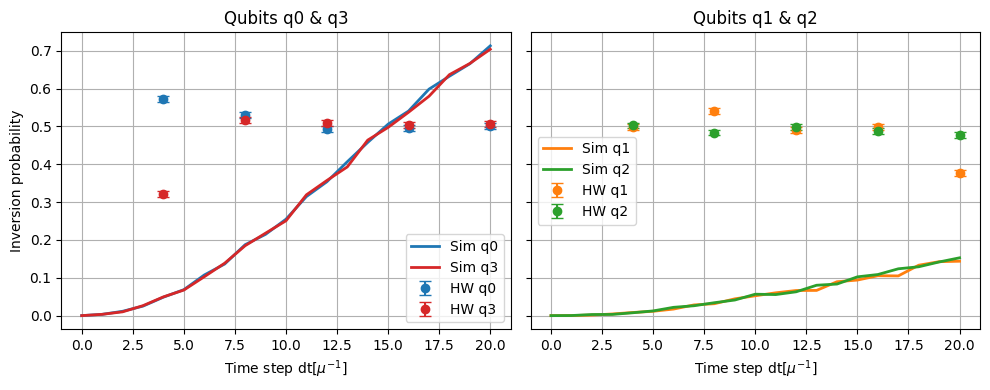

In [29]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

left_qubits  = [0, 3]
right_qubits = [1, 2]

# ===============================
# LEFT PANEL: q0, q3
# ===============================
ax = axes[0]

for q in left_qubits:

    color = f"C{q}"

    # --- Hardware ---
    y_hw = np.array(P_inv[q])
    err_hw = np.sqrt(y_hw * (1 - y_hw) / shots)

    ax.errorbar(
        times_hw,
        y_hw,
        yerr=err_hw,
        fmt='o',
        capsize=4,
        color=color,
        label=f"HW q{q}"
    )

    # --- Simulation ---
    y_sim = np.array(P_inv_sim[q])

    ax.plot(
        times_sim,
        y_sim,
        '-',
        linewidth=2,
        color=color,
        label=f"Sim q{q}"
    )

ax.set_title("Qubits q0 & q3")
ax.set_xlabel(r"Time step dt[$\mu^{-1}$]")
ax.set_ylabel("Inversion probability")
ax.grid(True)
ax.legend()


# ===============================
# RIGHT PANEL: q1, q2
# ===============================
ax = axes[1]

for q in right_qubits:

    color = f"C{q}"

    # --- Hardware ---
    y_hw = np.array(P_inv[q])
    err_hw = np.sqrt(y_hw * (1 - y_hw) / shots)

    ax.errorbar(
        times_hw,
        y_hw,
        yerr=err_hw,
        fmt='o',
        capsize=4,
        color=color,
        label=f"HW q{q}"
    )

    # --- Simulation ---
    y_sim = np.array(P_inv_sim[q])

    ax.plot(
        times_sim,
        y_sim,
        '-',
        linewidth=2,
        color=color,
        label=f"Sim q{q}"
    )

ax.set_title("Qubits q1 & q2")
ax.set_xlabel(r"Time step dt[$\mu^{-1}$]")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
from qiskit import QuantumCircuit, transpile

# --- Build logical circuit (2 qubits example) ---
qc = QuantumCircuit(2, 2)

qc.x(1)

# Hardware-friendly interaction (or original if only 2 qubits)
add_interaction_evolution_hw(qc, n=1, J=J, N=2)

# Draw logical circuit (before mapping)
qc.draw('mpl')
qc_dec=qc.decompose()
#qc_dec.draw(output="latex_source", filename="circuit.tex")

print(qc_dec.draw(output="text"))

        ┌───┐                                    ┌───┐┌──────┐     »
q_0: ───┤ H ├───────────■─────────────────────■──┤ H ├┤ √Xdg ├──■──»
     ┌──┴───┴───┐┌───┐┌─┴─┐┌───────────────┐┌─┴─┐├───┤├──────┤┌─┴─┐»
q_1: ┤ U(π,0,π) ├┤ H ├┤ X ├┤ Rz(0.0056401) ├┤ X ├┤ H ├┤ √Xdg ├┤ X ├»
     └──────────┘└───┘└───┘└───────────────┘└───┘└───┘└──────┘└───┘»
c: 2/══════════════════════════════════════════════════════════════»
                                                                   »
«                           ┌────┐                           
«q_0: ───────────────────■──┤ √X ├──■─────────────────────■──
«     ┌───────────────┐┌─┴─┐├────┤┌─┴─┐┌───────────────┐┌─┴─┐
«q_1: ┤ Rz(0.0056401) ├┤ X ├┤ √X ├┤ X ├┤ Rz(0.0056401) ├┤ X ├
«     └───────────────┘└───┘└────┘└───┘└───────────────┘└───┘
«c: 2/═══════════════════════════════════════════════════════
«                                                            


In [18]:
# Map to hardware topology
tqc = transpile(
    qc,
    backend,
    optimization_level=1
)
print(tqc.draw(output="text"))
tqc.draw(output="latex_source", filename="hardware_circuit.tex")

global phase: 5π/4
         ┌─────────┐┌────┐┌─────────┐                                        »
q_0 -> 0 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■──────────────────────────────────────»
         └──┬───┬──┘└────┘└─────────┘ │ ┌─────────┐┌────┐┌────────────┐┌────┐»
q_1 -> 1 ───┤ X ├─────────────────────■─┤ Rz(π/2) ├┤ √X ├┤ Rz(-3.136) ├┤ √X ├»
            └───┘                       └─────────┘└────┘└────────────┘└────┘»
«                          ┌────┐  ┌─────────┐                    »
«q_0 -> 0 ────────────■────┤ √X ├──┤ Rz(π/2) ├─■──────────────────»
«         ┌─────────┐ │ ┌──┴────┴─┐└──┬────┬─┘ │ ┌─────────┐┌────┐»
«q_1 -> 1 ┤ Rz(π/2) ├─■─┤ Rz(π/2) ├───┤ √X ├───■─┤ Rz(π/2) ├┤ √X ├»
«         └─────────┘   └─────────┘   └────┘     └─────────┘└────┘»
«                                              ┌────┐                      »
«q_0 -> 0 ────────────────────────────────■────┤ √X ├───■──────────────────»
«         ┌────────────┐┌────┐┌─────────┐ │ ┌──┴────┴─┐ │ ┌─────────┐┌────┐»
«q_1 -> 1 ┤ Rz(

'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{{$\\mathrm{global\\,phase:\\,} \\mathrm{\\frac{5\\pi}{4}}$}\n\\Qcircuit @C=1.0em @R=0.2em @!R { \\\\\n\t \t\\nghost{{q}_{0}\\;\\mapsto\\;{0} :  } & \\lstick{{q}_{0}\\;\\mapsto\\;{0} :  } & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\gate{\\mathrm{\\sqrt{X}}} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\ctrl{1} & \\qw & \\qw & \\qw & \\qw & \\qw & \\ctrl{1} & \\gate{\\mathrm{\\sqrt{X}}} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\ctrl{1} & \\qw & \\qw & \\qw & \\qw & \\qw & \\ctrl{1} & \\gate{\\mathrm{\\sqrt{X}}} & \\ctrl{1} & \\qw & \\qw & \\qw & \\qw & \\qw & \\ctrl{1} & \\qw & \\qw & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1}\\;\\mapsto\\;{1} :  } & \\lstick{{q}_{1}\\;\\mapsto\\;{1} :  } & \\gate{\\mathrm{X}} & \\qw & \\qw & \\control\\qw & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\gate{\\m

In [24]:
## Run with M3 error mitigation
import mthree

initial_bits = [0, 0, 1, 1]

# Interaction matrix
N=4
J = interaction_matrix(N, dm2, E)

# Initial state
qc0 = QuantumCircuit(N, N)
qc0.x(2)
qc0.x(3)

P_inv_error = [[] for _ in range(N)]
times = []

shots = 4096
time_points = np.linspace(4, 40, 10, dtype=int)

# ===============================
# M3 CALIBRATION
# ===============================
mit = mthree.M3Mitigation(backend)
mit.cals_from_system(range(N))

circuits = []

# ---------- Build circuits ----------
for n in time_points:

    qc = qc0.copy()

    add_interaction_evolution_hw(qc, n=n, J=J, N=N)

    qc.measure(range(N), range(N))

    tqc = transpile(
        qc,
        backend,
        optimization_level=1,
        scheduling_method="alap"
    )

    circuits.append(tqc)

# ---------- Run job ----------
job = sampler.run(circuits, shots=shots)

print("Job ID:", job.job_id())

result = job.result()

# ---------- Process results with M3 ----------
for idx, n in enumerate(time_points):

    raw_counts = result[idx].data.c.get_counts()

    # ⭐ Apply measurement mitigation
    mitigated_probs = mit.apply_correction(raw_counts, range(N))

    p_inv_t = [0.0] * N

    # Note: M3 returns probabilities, not counts
    for bitstring, prob in mitigated_probs.items():

        for q in range(N):
            bit_q = int(bitstring[-1 - q])
            if bit_q != initial_bits[q]:
                p_inv_t[q] += prob

    times.append(n)

    for q in range(N):
        P_inv_error[q].append(p_inv_t[q])

    print(
        f"t = {n:2d} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f}, "
        f"q2_inv = {p_inv_t[2]:.4f}, "
        f"q3_inv = {p_inv_t[3]:.4f}"
    )

Job ID: d70isoc69uic73ckdbo0
t =  4 | q0_inv = 0.2377, q1_inv = 0.4277, q2_inv = 0.4477, q3_inv = 0.3420
t =  8 | q0_inv = 0.2790, q1_inv = 0.2598, q2_inv = 0.3209, q3_inv = 0.6396
t = 12 | q0_inv = 0.3164, q1_inv = 0.4241, q2_inv = 0.4784, q3_inv = 0.5821
t = 16 | q0_inv = 0.3186, q1_inv = 0.3787, q2_inv = 0.4730, q3_inv = 0.4697
t = 20 | q0_inv = 0.3234, q1_inv = 0.4496, q2_inv = 0.5414, q3_inv = 0.5141
t = 24 | q0_inv = 0.3398, q1_inv = 0.4210, q2_inv = 0.5493, q3_inv = 0.5708
t = 28 | q0_inv = 0.3479, q1_inv = 0.4462, q2_inv = 0.5531, q3_inv = 0.5758
t = 32 | q0_inv = 0.3459, q1_inv = 0.4429, q2_inv = 0.5536, q3_inv = 0.5761
t = 36 | q0_inv = 0.3441, q1_inv = 0.4320, q2_inv = 0.5508, q3_inv = 0.5851
t = 40 | q0_inv = 0.3615, q1_inv = 0.4362, q2_inv = 0.5590, q3_inv = 0.5993


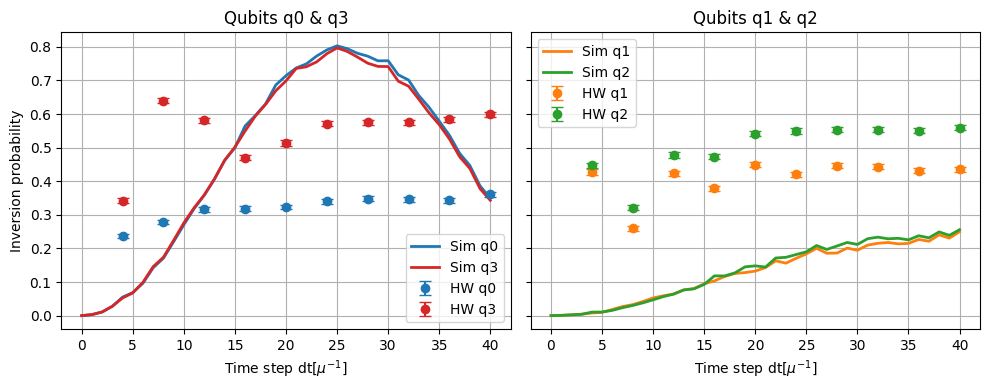

In [25]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

left_qubits  = [0, 3]
right_qubits = [1, 2]

# ===============================
# LEFT PANEL: q0, q3
# ===============================
ax = axes[0]

for q in left_qubits:

    color = f"C{q}"

    # --- Hardware ---
    y_hw = np.array(P_inv_error[q])
    err_hw = np.sqrt(y_hw * (1 - y_hw) / shots)

    ax.errorbar(
        times,
        y_hw,
        yerr=err_hw,
        fmt='o',
        capsize=4,
        color=color,
        label=f"HW q{q}"
    )

    # --- Simulation ---
    y_sim = np.array(P_inv_sim[q])

    ax.plot(
        times_sim,
        y_sim,
        '-',
        linewidth=2,
        color=color,
        label=f"Sim q{q}"
    )

ax.set_title("Qubits q0 & q3")
ax.set_xlabel(r"Time step dt[$\mu^{-1}$]")
ax.set_ylabel("Inversion probability")
ax.grid(True)
ax.legend()


# ===============================
# RIGHT PANEL: q1, q2
# ===============================
ax = axes[1]

for q in right_qubits:

    color = f"C{q}"

    # --- Hardware ---
    y_hw = np.array(P_inv_error[q])
    err_hw = np.sqrt(y_hw * (1 - y_hw) / shots)

    ax.errorbar(
        times,
        y_hw,
        yerr=err_hw,
        fmt='o',
        capsize=4,
        color=color,
        label=f"HW q{q}"
    )

    # --- Simulation ---
    y_sim = np.array(P_inv_sim[q])

    ax.plot(
        times_sim,
        y_sim,
        '-',
        linewidth=2,
        color=color,
        label=f"Sim q{q}"
    )

ax.set_title("Qubits q1 & q2")
ax.set_xlabel(r"Time step dt[$\mu^{-1}$]")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()